In [1]:
import pathlib

from functools import cache

import pandas as pd
import swifter

from matplotlib import pyplot as plt
from rdkit import Chem
from tqdm.auto import tqdm

In [2]:
NOTEBOOK_DIR = pathlib.Path().absolute()
DATA_DIR = NOTEBOOK_DIR.parents[1] / "data" / "solvation"
QUANTUM_GREEN_DIR = pathlib.Path("/home/shared/projects/quantum_green")
PAPER_DATA_DIR = QUANTUM_GREEN_DIR / "paper" / "data"
PAPER_FIGURE_DIR = QUANTUM_GREEN_DIR / "paper" / "figure" / "section_3_1_2_ts_char"
SUPERCLOUD_DIR = QUANTUM_GREEN_DIR / "supercloud_xfer" / "cosmo"
RESULTS_CSV_DIR = SUPERCLOUD_DIR / "ts_26may5" / "results" / "csv"

In [3]:
@cache
def canonical_smiles(smiles):
    mol = Chem.MolFromSmiles(smiles)
    for atom in mol.GetAtoms():
        atom.SetAtomMapNum(0)
    return Chem.MolToSmiles(mol, isomericSmiles=False)


def first_letter(name):
    return next(s for s in name if s.isalpha())


pd.set_option("display.max_columns", None)


def head(df, n=2):
    display(df.head(n))
    print(f"Contains {len(df)} rows")


def clean_rxn_smi(rxn_smi):
    return ">>".join(
        [
            ".".join([canonical_smiles(smi) for smi in category.split(".")])
            for category in rxn_smi.split(">>")
        ]
    )


def get_rxn_smi(row):
    return clean_rxn_smi(
        row["r1"] + "." + row["r2"] + ">>" + row["p1"] + "." + row["p2"]
    )

In [4]:
solvents_df = pd.read_csv(pathlib.Path.cwd() / "solvents.csv")
solvents_df["smiles"] = solvents_df["smiles"].swifter.apply(canonical_smiles)
head(solvents_df)

Pandas Apply:   0%|          | 0/295 [00:00<?, ?it/s]

,cosmo_name,smiles,inchi,cosmo_conf,source,exp_dielectric,T,source.1,polar,protic
0,"(1,1-dimethylethyl)benzene",CC(C)(C)c1ccccc1,"InChI=1/C10H14/c1-10(2,3)9-7-5-4-6-8-9/h4-8H,1...",1,COSMObase,2.359,20.0,NaN,0.0,0
1,"1-(1,1-dimethylethoxy)-2-propanol",CC(O)COC(C)(C)C,"InChI=1/C7H16O2/c1-6(8)5-9-7(2,3)4/h6,8H,5H2,1...",5,COSMObase,NaN,NaN,NaN,NaN,1


Contains 295 rows


In [5]:
solvent_mapping = solvents_df.set_index("smiles")["cosmo_name"].to_dict()

## Transition State Data

In [6]:
ts_data = pd.read_pickle(
    PAPER_FIGURE_DIR / "quantum_green_ts_data_24july2c.pkl"
)
ts_data["rxn_smi"] = ts_data["smiles"].swifter.apply(clean_rxn_smi)
head(ts_data)

Pandas Apply:   0%|          | 0/167237 [00:00<?, ?it/s]

,ts_dft_log_source_utf_8_sha512,dft_table_id,ts_dft_log_path,ts_dft_route_section,charge,multiplicity,ts_dft_opt_max_steps,ts_dft_opt_normal_termination_check,ts_dft_opt_cpu_time,ts_dft_opt_wall_time,ts_dft_sum_of_electronic_and_thermal_enthalpies_hartree,ts_dft_hartreefock_energy_hartree,ts_dft_zpe_hartree,ts_dft_e0_zpe_hartree,ts_dft_gibbs_hartree,ts_dft_scf_hartree,ts_dft_frequency_modes,ts_dft_std_forces,ts_dft_opted_std_xyz,ts_dft_opted_xyz_input_orientation,is_ts,batch_label,ts_dft_log_filename_id,rsmi,psmi,r1smi,r2smi,p1smi,p2smi,r1nasmi,r2nasmi,p1nasmi,p2nasmi,std_xyz_str,xyz_str,p1_reaction_center_atom_map_num,r1_reaction_center_atom_map_num,h_atom_map_num,r1_matched_sha512,r2_matched_sha512,p1_matched_sha512,p2_matched_sha512,r1_matched_smi,r1_matched_std_xyz_str,r2_matched_smi,r2_matched_std_xyz_str,p1_matched_smi,p1_matched_std_xyz_str,p2_matched_smi,p2_matched_std_xyz_str,connectivity_check_r1,connectivity_check_r2,connectivity_check_r1_dist,connectivity_check_r2_dist,r2_h_idx,r2_reacting_site_idx,r2_reacting_site_element,r2_reacting_site_h_bond_distance,r2_ts_reacting_site_h_bond_distance,r2_ts_reacting_site_h_bond_distance_pct_change,connectivity_check_p1,connectivity_check_p2,connectivity_check_p1_dist,connectivity_check_p2_dist,p2_h_idx,p2_reacting_site_idx,p2_reacting_site_element,p2_reacting_site_h_bond_distance,p2_ts_reacting_site_h_bond_distance,p2_ts_reacting_site_h_bond_distance_pct_change,rxn_smi,fingerprint,rxn_smi_original_order,rdmc_large_factor,rdmc_small_factor,neg_freq,neg_freq_z_score,rp_connectivity_check_true_sum,connectivity_check_r1_score,connectivity_check_r2_score,connectivity_check_p2_score,connectivity_check_p1_score,ho2_ts_h_mode,ho2_non_react_h_mode,ho2_ts_h_score,ho2_non_react_h_score,ho2_non_div_ts_mode_ratio,r1_dft_e0_zpe_hartree,r2_dft_e0_zpe_hartree,p1_dft_e0_zpe_hartree,p2_dft_e0_zpe_hartree,rcomplex_dft_e0_zpe_hartree,pcomplex_dft_e0_zpe_hartree,dft_fwd_barrier_e0_zpe_hartree,dft_rev_barrier_e0_zpe_hartree,dft_fwd_Hrxn_e0_zpe_hartree,dft_fwd_barrier_e0_zpe_kcal,dft_rev_barrier_e0_zpe_kcal,dft_fwd_Hrxn_e0_zpe_kcal,ts_dlpno_log_filename_id,ts_dlpno_xyz_tuple,ts_dlpno_log_path,ts_dlpno_sp_hartree,dft_opted_xyz_tuple_used_for_dlpno_calc,r1_dlpno_sp_hartree,r2_dlpno_sp_hartree,p1_dlpno_sp_hartree,p2_dlpno_sp_hartree,all_species_has_dlpno_sp,fwd_Hrxn_dlpno_sp_hartree,ts_and_species_has_dlpno_sp,fwd_barrier_dlpno_sp_hartree,rev_barrier_dlpno_sp_hartree,fwd_Hrxn_dlpno_sp_kcal,fwd_barrier_dlpno_sp_kcal,rev_barrier_dlpno_sp_kcal,r1_dft_log_path,r2_dft_log_path,p1_dft_log_path,p2_dft_log_path,r1_dlpno_log_path,r2_dlpno_log_path,p1_dlpno_log_path,p2_dlpno_log_path,r1_dft_hartreefock_energy_hartree,r2_dft_hartreefock_energy_hartree,p1_dft_hartreefock_energy_hartree,p2_dft_hartreefock_energy_hartree,r1_dft_zpe_hartree,r2_dft_zpe_hartree,p1_dft_zpe_hartree,p2_dft_zpe_hartree,ts_and_species_has_dft_zpe,species_has_dft_zpe,fwd_Hrxn_dft_zpe_hartree,fwd_barrier_dft_zpe_hartree,rev_barrier_dft_zpe_hartree,fwd_Hrxn_dlpno_sp_dft_zpe_hartree,fwd_barrier_dlpno_sp_dft_zpe_hartree,rev_barrier_dlpno_sp_dft_zpe_hartree,fwd_Hrxn_dlpno_sp_dft_zpe_kcal,fwd_barrier_dlpno_sp_dft_zpe_kcal,rev_barrier_dlpno_sp_dft_zpe_kcal,r1_dft_zpe_scaled_hartree,r2_dft_zpe_scaled_hartree,p1_dft_zpe_scaled_hartree,p2_dft_zpe_scaled_hartree,ts_dft_zpe_scaled_hartree,fwd_barrier_dlpno_sp_dft_zpe_scaled_hartree,rev_barrier_dlpno_sp_dft_zpe_scaled_hartree,fwd_Hrxn_dlpno_sp_dft_zpe_scaled_hartree,rev_Hrxn_dlpno_sp_dft_zpe_scaled_hartree,fwd_barrier_dlpno_sp_dft_zpe_scaled_kcal,rev_barrier_dlpno_sp_dft_zpe_scaled_kcal,fwd_Hrxn_dlpno_sp_dft_zpe_scaled_kcal,rev_Hrxn_dlpno_sp_dft_zpe_scaled_kcal,ts_dft_frequencies,r1_dft_frequencies,r2_dft_frequencies,p1_dft_frequencies,p2_dft_frequencies,smiles
0,4c648a435eb66f655a9afa7aebe1b6288cfbe5d4377ab7...,545983,/home/gridsan/groups/RMG/Projects/Habs/data/ts...,"P opt=(ts,calcall,maxcycle=64,noeig,nomicro,ca...",0,2,64,True,53637.5,1178.8,-499.312919,-499.513846,0.187656,-499.326190,-499.365824,4

Contains 167237 rows


In [7]:
def as_str(x):
    return str(int(x)) if isinstance(x, float) else x

ts_mapping = dict(
    zip(ts_data["ts_dlpno_log_filename_id"].apply(as_str), ts_data["rxn_smi"])
)

## Reaction data

In [8]:
nov17_data = pd.read_csv(
    PAPER_DATA_DIR
    / "ts_solvation"
    / "FINAL_dG_solv_pruned_nov17_with_reactant_product_dGsolv.csv",
)
for col in ["solvent_smiles", "r1", "r2", "p1", "p2"]:
    nov17_data[col] = (
        nov17_data[col]
        .swifter.progress_bar(True, desc=f"Normalizing {col}")
        .apply(canonical_smiles)
    )
nov17_data["solute_smiles"] = nov17_data["solute_name"].astype(str).map(ts_mapping)
nov17_data["batch"] = "nov17"
nov17_data["mixture"] = nov17_data["solute_smiles"] + "." + nov17_data["solvent_smiles"]
nov17_data.drop_duplicates(subset=["mixture"], keep="first", inplace=True)
nov17_data.reset_index(drop=True, inplace=True)
head(nov17_data)

Normalizing solvent_smiles:   0%|          | 0/21684582 [00:00<?, ?it/s]

Normalizing r1:   0%|          | 0/21684582 [00:00<?, ?it/s]

Normalizing r2:   0%|          | 0/21684582 [00:00<?, ?it/s]

Normalizing p1:   0%|          | 0/21684582 [00:00<?, ?it/s]

Normalizing p2:   0%|          | 0/21684582 [00:00<?, ?it/s]

,solvent_smiles,solute_name,solute_smiles,Gsolv (kcal/mol),Hsolv (kcal/mol),r1,r2,p1,p2,r1_Gsolv,r2_Gsolv,p1_Gsolv,p2_Gsolv,DDGsolv_forward (kcal/mol),DDGsolv_reverse (kcal/mol),r1_Hsolv,r2_Hsolv,p1_Hsolv,p2_Hsolv,DDHsolv_forward (kcal/mol),DDHsolv_reverse (kcal/mol),batch,mixture
0,CCCCOP(=O)(OCCCC)OCCCC,52940,[O]O.CN1CC2CNCC2C1>>CN1CC2C[N]CC2C1.OO,-12.065855,-21.383296,[O]O,CN1CC2CNCC2C1,CN1CC2C[N]CC2C1,OO,-7.216970,-7.000390,-6.952042,-8.106657,2.151504,2.992844,-13.229345,-12.452517,-12.267439,-16.955998,4.298566,7.840141,nov17,[O]O.CN1CC2CNCC2C1>>CN1CC2C[N]CC2C1.OO.CCCCOP(...
1,CCCCCCCCCCCCC,52940,[O]O.CN1CC2CNCC2C1>>CN1CC2C[N]CC2C1.OO,-7.794416,-14.052868,[O]O,CN1CC2CNCC2C1,CN1CC2C[N]CC2C1,OO,-0.905423,-6.425314,-6.485875,-1.134200,-0.463679,-0.174341,-3.678896,-11.593300,-11.621092,-4.325111,1.219328,1.893335,nov17,[O]O.CN1CC2CNCC2C1>>CN1CC2C[N]CC2C1.OO.CCCCCCC...


Contains 21684576 rows


In [9]:
may5_data = pd.read_pickle(NOTEBOOK_DIR / "may5_reaction_data.pkl")
may5_data["batch"] = "may5"
may5_data["mixture"] = may5_data["solute_smiles"] + "." + may5_data["solvent_smiles"]
may5_data.drop_duplicates(subset=["mixture"], keep="first", inplace=True)
may5_data.reset_index(drop=True, inplace=True)
head(may5_data)

,solvent_smiles,solute_name,solute_smiles,Gsolv (kcal/mol),Hsolv (kcal/mol),r1,r2,p1,p2,r1_Gsolv,r2_Gsolv,p1_Gsolv,p2_Gsolv,DDGsolv_forward (kcal/mol),DDGsolv_reverse (kcal/mol),r1_Hsolv,r2_Hsolv,p1_Hsolv,p2_Hsolv,DDHsolv_forward (kcal/mol),DDHsolv_reverse (kcal/mol),batch,mixture
0,CC(C)(C)c1ccccc1,id54674,[O]O.CC(CC=O)C1CC1>>C[C](CC=O)C1CC1.OO,-7.885129,-13.646535,[O]O,CC(CC=O)C1CC1,C[C](CC=O)C1CC1,OO,-1.826162,-5.854218,-5.835240,-2.240731,-0.204749,0.190842,-4.68554,-10.122564,-10.122729,-5.641548,1.16157,2.117743,may5,[O]O.CC(CC=O)C1CC1>>C[C](CC=O)C1CC1.OO.CC(C)(C...
1,CC(C)(C)c1ccccc1,id55203,[O]O.COCC(C)OC1CC1>>[CH2]OCC(C)OC1CC1.OO,-7.813005,-14.251511,[O]O,COCC(C)OC1CC1,[CH2]OCC(C)OC1CC1,OO,-1.826162,-5.516928,-5.148951,-2.240731,-0.469915,-0.423323,-4.68554,-10.116941,-9.630907,-5.641548,0.55097,1.020944,may5,[O]O.COCC(C)OC1CC1>>[CH2]OCC(C)OC1CC1.OO.CC(C)...


Contains 26463565 rows


## Compare distributions in both batches

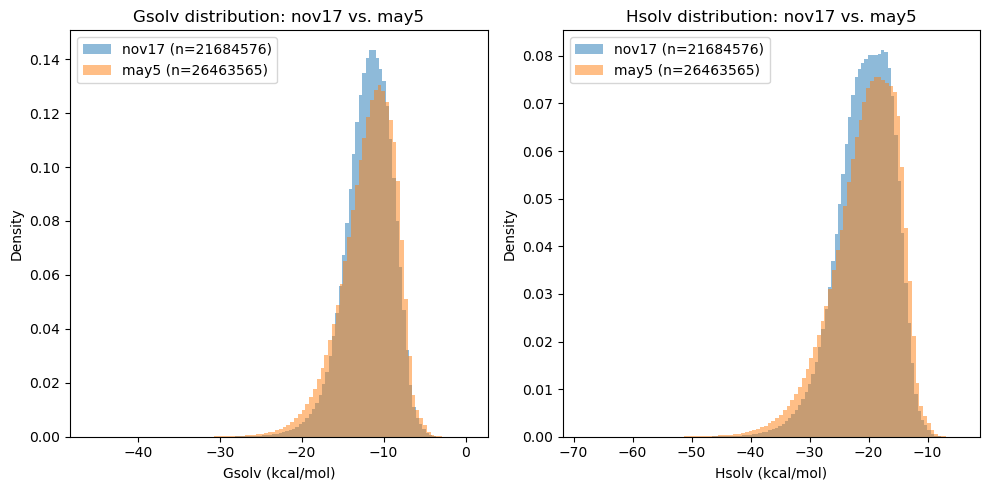

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
bins = 100
for ax, prop in zip(axes, ["Gsolv", "Hsolv"]):
    for df in [nov17_data, may5_data]:
        ax.hist(
            df[f"{prop} (kcal/mol)"].dropna(),
            bins=bins,
            alpha=0.5,
            density=True,
            label=f"{df['batch'].unique()[0]} (n={len(df)})",
        )
    ax.set_xlabel(f"{prop} (kcal/mol)")
    ax.set_ylabel("Density")
    ax.set_title(f"{prop} distribution: nov17 vs. may5")
    ax.legend()
plt.tight_layout()
plt.show()

## Compare overlapping mixtures

In [11]:
overlap = set(may5_data["solute_name"]) & set(nov17_data["solute_name"].astype(str))

nov17_overlap = nov17_data[
    nov17_data["solute_name"].astype(str).isin(overlap)
].copy()
head(nov17_overlap)

may5_overlap = may5_data[may5_data["solute_name"].isin(overlap)].copy()
head(may5_overlap)

,solvent_smiles,solute_name,solute_smiles,Gsolv (kcal/mol),Hsolv (kcal/mol),r1,r2,p1,p2,r1_Gsolv,r2_Gsolv,p1_Gsolv,p2_Gsolv,DDGsolv_forward (kcal/mol),DDGsolv_reverse (kcal/mol),r1_Hsolv,r2_Hsolv,p1_Hsolv,p2_Hsolv,DDHsolv_forward (kcal/mol),DDHsolv_reverse (kcal/mol),batch,mixture
3498541,O,81719,[O]OCO.OCC1=NC(CO)CN1>>OCC1=NC(CO)C[N]1.OCOO,-11.892459,-22.854163,[O]OCO,OCC1=NC(CO)CN1,OCC1=NC(CO)C[N]1,OCOO,-4.635473,-11.161416,NaN,-8.490203,3.904430,NaN,-8.629404,-21.167473,NaN,-14.559781,6.942715,NaN,nov17,[O]OCO.OCC1=NC(CO)CN1>>OCC1=NC(CO)C[N]1.OCOO.O
3498542,CCCCCCCCO,81719,[O]OCO.OCC1=NC(CO)CN1>>OCC1=NC(CO)C[N]1.OCOO,-11.078154,-19.919159,[O]OCO,OCC1=NC(CO)CN1,OCC1=NC(CO)C[N]1,OCOO,-4.653377,-9.875389,NaN,-7.174202,3.450612,NaN,-10.530046,-16.764870,NaN,-15.997107,7.375757,NaN,nov17,[O]OCO.OCC1=NC(CO)CN1>>OCC1=NC(CO)C[N]1.OCOO.C...


Contains 2360 rows


,solvent_smiles,solute_name,solute_smiles,Gsolv (kcal/mol),Hsolv (kcal/mol),r1,r2,p1,p2,r1_Gsolv,r2_Gsolv,p1_Gsolv,p2_Gsolv,DDGsolv_forward (kcal/mol),DDGsolv_reverse (kcal/mol),r1_Hsolv,r2_Hsolv,p1_Hsolv,p2_Hsolv,DDHsolv_forward (kcal/mol),DDHsolv_reverse (kcal/mol),batch,mixture
89699,CC(C)(C)c1ccccc1,37509,[O]O.C#CC(C)CNCC=CC>>C#CC(C)C[N]CC=CC.OO,-8.686736,-15.595572,[O]O,C#CC(C)CNCC=CC,C#CC(C)C[N]CC=CC,OO,-1.826162,-6.271595,-6.615306,-2.240731,-0.588979,0.169302,-4.68554,-11.541173,-11.998571,-5.641548,0.631141,2.044548,may5,[O]O.C#CC(C)CNCC=CC>>C#CC(C)C[N]CC=CC.OO.CC(C)...
89700,CC(C)(C)c1ccccc1,32204,[O]O.CC(=O)NCCC1CO1>>CC(=O)[N]CCC1CO1.OO,-8.799431,-15.751102,[O]O,CC(=O)NCCC1CO1,CC(=O)[N]CCC1CO1,OO,-1.826162,-8.231178,-6.723994,-2.240731,1.257910,0.165295,-4.68554,-13.800451,-12.306641,-5.641548,2.734889,2.197087,may5,[O]O.CC(=O)NCCC1CO1>>CC(=O)[N]CCC1CO1.OO.CC(C)...


Contains 2360 rows


In [12]:
overlap_df = pd.DataFrame(
    {
        "solute": nov17_overlap["solute_name"].astype(str),
        "solvent": nov17_overlap["solvent_smiles"],
        "Gsolv (legacy)": nov17_overlap["Gsolv (kcal/mol)"],
        "Hsolv (legacy)": nov17_overlap["Hsolv (kcal/mol)"],
        "Gsolv (new)": nov17_overlap["mixture"].map(
            may5_overlap.set_index("mixture")["Gsolv (kcal/mol)"]
        ),
        "Hsolv (new)": nov17_overlap["mixture"].map(
            may5_overlap.set_index("mixture")["Hsolv (kcal/mol)"]
        ),
    }
)
overlap_df["Gsolv_diff"] = overlap_df["Gsolv (legacy)"] - overlap_df["Gsolv (new)"]
overlap_df["Hsolv_diff"] = overlap_df["Hsolv (legacy)"] - overlap_df["Hsolv (new)"]
head(overlap_df)

,solute,solvent,Gsolv (legacy),Hsolv (legacy),Gsolv (new),Hsolv (new),Gsolv_diff,Hsolv_diff
3498541,81719,O,-11.892459,-22.854163,-11.892459,-22.854163,0.0,2.501039e-10
3498542,81719,CCCCCCCCO,-11.078154,-19.919159,-11.078154,-19.919159,0.0,1.250005e-09


Contains 2360 rows


In [13]:
overlap_df[["Gsolv_diff", "Hsolv_diff"]].describe()

,Gsolv_diff,Hsolv_diff
count,2.360000e+03,2.360000e+03
mean,4.237288e-12,1.245864e-09
std,2.058468e-10,8.679784e-08
min,0.000000e+00,-1.492250e-06
25%,0.000000e+00,-2.499967e-09
50%,0.000000e+00,1.509903e-14
75%,0.000000e+00,2.499976e-09
max,1.000000e-08,1.493500e-06


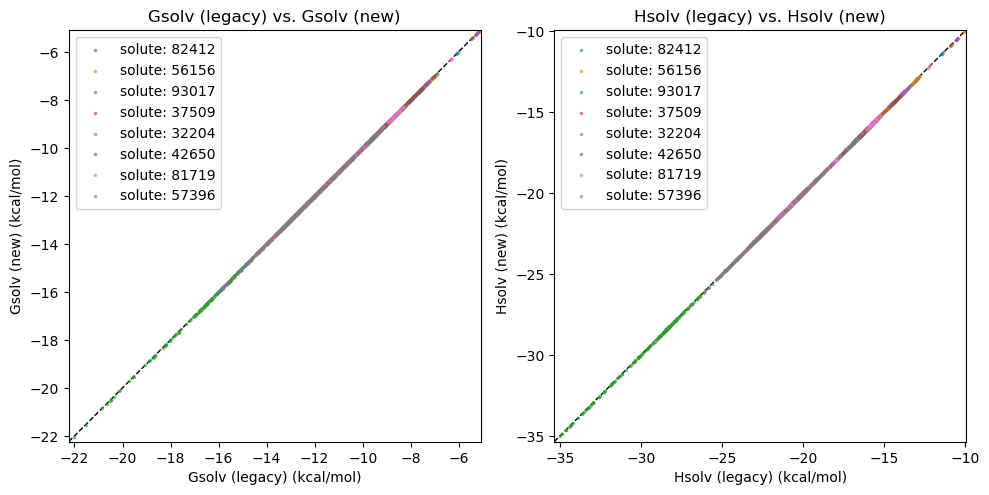

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
for ax, prop in zip(axes, ["Gsolv", "Hsolv"]):
    values = (
        overlap_df[f"{prop} (legacy)"].to_list() + overlap_df[f"{prop} (new)"].to_list()
    )
    min_val = min(values)
    max_val = max(values)
    ax.plot(
        [min_val, max_val],
        [min_val, max_val],
        color="black",
        lw=1,
        linestyle="--",
        zorder=0,
    )
    for solute in overlap:
        df = overlap_df[overlap_df["solute"] == solute]
        ax.scatter(
            df[f"{prop} (legacy)"],
            df[f"{prop} (new)"],
            alpha=0.5,
            marker=".",
            s=10,
            label=f"solute: {solute}",
            zorder=1,
        )
    ax.set_xlim(min_val, max_val)
    ax.set_ylim(min_val, max_val)
    ax.set_xlabel(f"{prop} (legacy) (kcal/mol)")
    ax.set_ylabel(f"{prop} (new) (kcal/mol)")
    ax.set_title(f"{prop} (legacy) vs. {prop} (new)")
    ax.legend()
    ax.set_aspect("equal")
fig.tight_layout()
plt.show()

## Concatenate data

In [15]:
all_data = pd.concat(
    [nov17_data, may5_data[~may5_data["solute_name"].isin(overlap)]], ignore_index=True
)
head(all_data)

,solvent_smiles,solute_name,solute_smiles,Gsolv (kcal/mol),Hsolv (kcal/mol),r1,r2,p1,p2,r1_Gsolv,r2_Gsolv,p1_Gsolv,p2_Gsolv,DDGsolv_forward (kcal/mol),DDGsolv_reverse (kcal/mol),r1_Hsolv,r2_Hsolv,p1_Hsolv,p2_Hsolv,DDHsolv_forward (kcal/mol),DDHsolv_reverse (kcal/mol),batch,mixture
0,CCCCOP(=O)(OCCCC)OCCCC,52940,[O]O.CN1CC2CNCC2C1>>CN1CC2C[N]CC2C1.OO,-12.065855,-21.383296,[O]O,CN1CC2CNCC2C1,CN1CC2C[N]CC2C1,OO,-7.216970,-7.000390,-6.952042,-8.106657,2.151504,2.992844,-13.229345,-12.452517,-12.267439,-16.955998,4.298566,7.840141,nov17,[O]O.CN1CC2CNCC2C1>>CN1CC2C[N]CC2C1.OO.CCCCOP(...
1,CCCCCCCCCCCCC,52940,[O]O.CN1CC2CNCC2C1>>CN1CC2C[N]CC2C1.OO,-7.794416,-14.052868,[O]O,CN1CC2CNCC2C1,CN1CC2C[N]CC2C1,OO,-0.905423,-6.425314,-6.485875,-1.134200,-0.463679,-0.174341,-3.678896,-11.593300,-11.621092,-4.325111,1.219328,1.893335,nov17,[O]O.CN1CC2CNCC2C1>>CN1CC2C[N]CC2C1.OO.CCCCCCC...


Contains 48145781 rows


In [16]:
assert len(all_data) == len(set(all_data["mixture"]))

In [17]:
(PAPER_DATA_DIR / "new_ts_solvation").mkdir(parents=True, exist_ok=True)

all_data.drop(columns=["mixture"]).to_pickle(
    PAPER_DATA_DIR
    / "new_ts_solvation"
    / "FINAL_dG_solv_pruned_nov17_and_may5_with_reactant_product_dGsolv.pkl"
)

## Save transition state data

In [18]:
ts_current_columns = ["solute_smiles", "Gsolv (kcal/mol)", "Hsolv (kcal/mol)"]
ts_output_columns = ["smiles", "Gsolv", "Hsolv"]

In [ ]:
DIR = DATA_DIR / "quantumpioneer_solvation_dataset_transition_states"
DIR.mkdir(parents=True, exist_ok=True)
valid_ts = all_data.rename(
    columns=dict(zip(ts_current_columns, ts_output_columns))
).dropna(subset=ts_output_columns)
for solvent_smiles, group in tqdm(
    valid_ts.groupby("solvent_smiles"), total=all_data["solvent_smiles"].nunique()
):
    name = solvent_mapping[solvent_smiles]
    subdir = DIR / first_letter(name)
    subdir.mkdir(parents=True, exist_ok=True)
    group[ts_output_columns].to_csv(
        subdir / f"{name}.csv", index=False, float_format="%.10g"
    )

  0%|          | 0/295 [00:00<?, ?it/s]

In [20]:
len(valid_ts)

48145781

## Save reaction data

In [21]:
reaction_current_columns = [
    "solute_smiles",
    "DDGsolv_forward (kcal/mol)",
    "DDGsolv_reverse (kcal/mol)",
    "DDHsolv_forward (kcal/mol)",
    "DDHsolv_reverse (kcal/mol)",
]
reaction_output_columns = [
    "rxn_smiles",
    "DDGsolv_forward",
    "DDGsolv_reverse",
    "DDHsolv_forward",
    "DDHsolv_reverse",
]

In [ ]:
valid_reactions = all_data.rename(
    columns=dict(zip(reaction_current_columns, reaction_output_columns))
).dropna(subset=reaction_output_columns)
DIR = DATA_DIR / "quantumpioneer_solvation_dataset_reactions"
DIR.mkdir(parents=True, exist_ok=True)
for solvent_smiles, group in tqdm(
    valid_reactions.groupby("solvent_smiles"),
    total=all_data["solvent_smiles"].nunique(),
):
    name = solvent_mapping[solvent_smiles]
    subdir = DIR / first_letter(name)
    subdir.mkdir(parents=True, exist_ok=True)
    group[reaction_output_columns].to_csv(
        subdir / f"{name}.csv", index=False, float_format="%.10g"
    )

  0%|          | 0/295 [00:00<?, ?it/s]

In [23]:
len(valid_reactions)

47058175